#### Imports and Setups

In [1]:
from IPython.display import clear_output
from IPython.display import display
from urllib.parse import urljoin
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from pathlib import Path
import pandas as pd
import requests
import numpy as np
import time
import math
import csv
import re
import os

In [2]:
# Setups
pd.set_option("display.max_colwidth", None)

###### Database setup

In [3]:
from neo4j import GraphDatabase

URI = 'neo4j://localhost:7687'
AUTH = ('neo4j', 'password')
db = GraphDatabase.driver(URI, auth=AUTH)
db.verify_connectivity()


Unable to retrieve routing information


ServiceUnavailable: Unable to retrieve routing information

## Perils of Transitive Trust

### Obectives, Questions, and ToDos

Obectives
1. Quantify size of the DNS Trusted Computing Base(Dependency)
2. Impact of known DNS software vulnerabilities.
3. Identification DNS checkpoints: Name servers that directly or indirectly control many  names.

Questions answered from the paper.:

**Dependency**
1. How many DNS servers does it take to resolve a typical domain name?
2. What is the TCB for each domain, and how big is it really?
3. If we count by unique server names versus unique IPs, does the dependency size change much?
4. Are popular sites less dependent, or actually more dependent?
5. Dependency in TLD: ccTLD vs gTLD?
6. How many servers are directly designated by the domain owner, versus outside the owner’s control?
   
**Effects/Impact**
1. What happens if one of the dependent name servers is compromised: partial hijack or complete hijack?
2. How many servers would an attacker need to compromise to guarantee taking over a domain? This is the complete-hijack/min-cut question.

**Vulnerability**
1. How much of DNS is exposed because name servers run software with known vulnerabilities?
2. How many names can be hijacked using already known exploits in vulnerable DNS servers?
3. Which name servers are choke points, meaning they affect a very large number of domain names? 
4. Overall, does DNS delegation create hidden transitive trust that makes the real attack surface much larger than people think?



### Data Selection and Understanding


###### Selecting domains

Using Cisco Umbrella Top 1 Million Data.

Made up 71% Hostnames, and 29% Domains names and saving the names into namelist_cvs to be used later inthe queries

In [45]:
# Query testing, Getting the count for Cisco Umbrella Top 1 Million Data.
query = """
MATCH  (names:DomainName|HostName)-[:RANK]-(:Ranking{name:"Cisco Umbrella Top 1 million"})
RETURN count (names)
"""

records, _, keys = db.execute_query(query)
data_count = pd.DataFrame(records, columns=keys)
data_count

,count (names)
0,1000000


In [46]:
# Getting Cisco Umbrella Top 1 Million 
query = """
MATCH  (names:DomainName|HostName)-[:RANK]-(:Ranking{name:"Cisco Umbrella Top 1 million"})
RETURN names.name as names
"""

records, _, keys = db.execute_query(query)
names_df = pd.DataFrame(records, columns=keys)

names_df.head(2)

,names
0,exo-ring.msedge.net
1,dreamcatcher.asia.dob.sibl.support-intelligence.net


###### Understand the dataset first. What is the distribution of TLDs in the dataset? How much is ccTLD and how much is gTLD?

In [51]:
#extracting tld part on the names
names_df["tld"]=names_df["names"].str.extract(r"\.([^.]+)$")
print("Different TLD present in the dataset",names_df["tld"].nunique())

Different TLD present in the dataset 725


In [52]:
tld_grouped_size_df = names_df["tld"].value_counts(dropna=False)

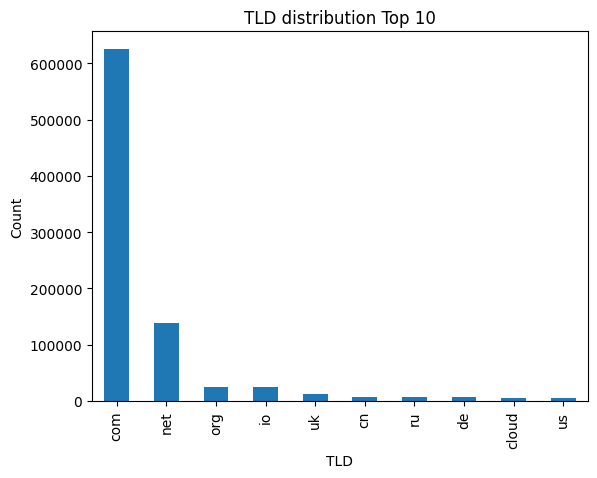

In [53]:
# peak at the distribution, Top 10 TLD distribution from the list.

top_ten_df =tld_grouped_size_df.head(10)
top_ten_df.plot.bar()
plt.ylabel("Count")
plt.xlabel("TLD")
plt.title("TLD distribution Top 10")
plt.show()

###### TLD classification

In [54]:

# Getting TLD type information from IANA, to categorize the Datasets.
url = "https://www.iana.org/domains/root/db"
html = requests.get(url).text
soup = BeautifulSoup(html, "html.parser")

rows = []
for tr in soup.select("table tbody tr"):
    tds = tr.find_all("td")
    if len(tds) >= 3:
        a = tds[0].find("a")
        Domain = a.get_text(strip=True) if a else tds[0].get_text(strip=True)
        href = a["href"] if a and a.has_attr("href") else None
        
        punycode = None
        if href:
            filename = href.split("/")[-1]
            punycode = filename.replace(".html", "")
        else:
            full_url = None

        rows.append({
            "Domain": Domain,
            "tld": punycode,
            "type": tds[1].get_text(" ", strip=True),
            "manager": tds[2].get_text(" ", strip=True),
        })

iana_list = pd.DataFrame(rows)
print("Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type")
print(iana_list[iana_list["Domain"] == ".餐厅"])
print("\n")
iana_list

Example of the results with reanded domain .餐厅 with its respective extracted punycode(tld)and type
     Domain          tld     type                                     manager
1481    .餐厅  xn--imr513n  generic  Internet DotTrademark Organisation Limited




,Domain,tld,type,manager
0,.aaa,aaa,generic,"American Automobile Association, Inc."
1,.aarp,aarp,generic,AARP
2,.abarth,abarth,generic,Not assigned
3,.abb,abb,generic,ABB Ltd
4,.abbott,abbott,generic,"Abbott Laboratories, Inc."
...,...,...,...,...
1589,.zippo,zippo,generic,Not assigned
1590,.zm,zm,country-code,Zambia Information and Communications Technology Authority (ZICTA)
1591,.zone,zone,generic,"Binky Moon, LLC"
1592,.zuerich,zuerich,generic,Kanton Zürich (Canton of Zurich)


In [55]:
# Mapping tld type From IANA to the names dataset, to categorize the dataset based on TLD type.

names_tldtype_df = names_df.merge(iana_list[[ "tld", "type" ]], on="tld", how="left")

names_tldtype_df.head(2)


#Saving categorized Cisco Umbrella Top 1 Million into a csv(to save query time). data\names\categorized_names.csv

try:
    out_dir = Path.cwd().parent / 'data' / 'names'
    out_dir.mkdir(parents=True, exist_ok=True)

    out_path = out_dir / 'categorized_names.parquet'
    names_tldtype_df.to_parquet(out_path, index=False)
    
except Exception as e:
    print(f"feiled:{e}")

###### Categorized name list from disk
`>>> Run from here upon restarting`

In [4]:
# From now on we will be using categorized name list saved  in   data\names\categorized_names.parquet
file_path = Path.cwd().parent / 'data' / 'names' /  'categorized_names.parquet'
names_tldtype_df = pd.read_parquet(file_path)
names_tldtype_df.head(2)

,names,tld,type
0,exo-ring.msedge.net,net,generic
1,dreamcatcher.asia.dob.sibl.support-intelligence.net,net,generic


In [5]:
names_tldtype_df["type"].value_counts(dropna=False)

type
generic               841753
country-code          143642
sponsored              11573
generic-restricted      2984
infrastructure            43
NaN                        5
Name: count, dtype: int64

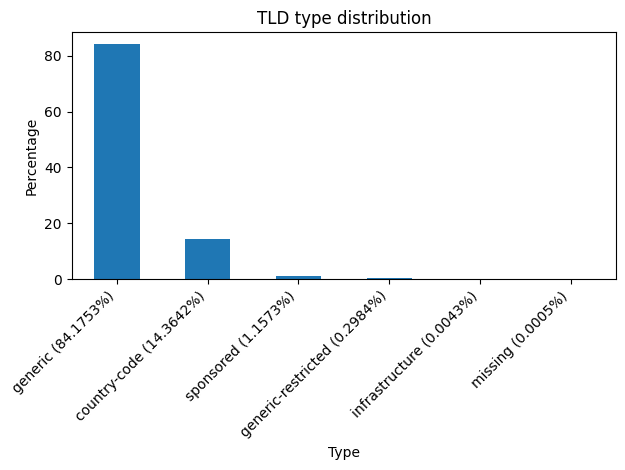

In [6]:
import matplotlib.pyplot as plt

type_pct = (
    names_tldtype_df["type"]
    .fillna("missing")
    .value_counts(normalize=True) * 100
)

labels = [f"{name} ({value:.4f}%)" for name, value in type_pct.items()]

ax = type_pct.plot.bar()
ax.set_xticklabels(labels, rotation=45, ha="right")


plt.ylabel("Percentage")
plt.xlabel("Type")
plt.title("TLD type distribution")
plt.tight_layout()
plt.show()

### Reconstruct the full dependency for each domain. What are all the DNS servers involved in resolving each domain, not only the directly listed authoritative servers?

#### Approach & Function Descriptions

Dependency Query, Extraction, and Summarization Functions

To analyze DNS relationships (depths), the approach relies on exploring valid dependency paths.

Example graph:
```
(a)-(b)-(c)-(d)-(f)
         |
        (e)
```
`apoc.path.expandConfig` returns all possible paths:
a-b, a-b-c, a-b-c-d, a-b-c-d-f, a-b-c-e


Not all returned paths are useful for dependency analysis. Prefix paths such as `a-b` or `a-b-c` are incomplete because they terminate before reaching a meaningful dependency endpoint. The focus is on structurally valid paths that end at authoritative nameservers.

Previously, filtering was performed in Python after fetching paths from Neo4j. This introduced unnecessary overhead for large datasets. The current approach moves filtering and dependency extraction into the Neo4j query.


###### Approach

The pipeline performs validation and dependency extraction directly in Neo4j:

- Traverse candidate dependency paths using APOC  
- Filter and keep only structurally valid paths inside the query  
- Extract dependency relationships and summaries in the query  
- Return compact results to Python for aggregation and storage  

This reduces data transfer and eliminates expensive client-side filtering.


###### Functions

**1. `fetch_paths(db, domain_name)`**  
Queries Neo4j for a given domain or hostname, resolves the correct starting domain, and traverses dependency paths using APOC.

Returns:
- **Summary-level data (per domain):**
  - `start_domain`
  - `TCB`
  - `all_unique_ns`
  - `dependencies`

- **Path-level data (per valid path):**
  - `start_domain`
  - `name_server_count`
  - `name_servers`
  - `path_list`

The Trusted Computing Base (TCB) is defined as the set of unique authoritative nameservers observed across all valid paths.


**2. `finding_dipendency(list_of_names)`**  
Iterates over a list of domains, calls `fetch_paths` for each, and aggregates results into:
- a domain-level summary list  
- a path-level dependency list  

Includes periodic progress reporting during execution.


**3. `summarize_domain(group)`**  
Aggregates path-level results grouped by `start_domain`.

Computes:
- shortest path size  
- longest path size  
- average path size  
- number of distinct paths  
- representative shortest path  
- representative longest path  

Provides a compact per-domain view of dependency depth and variation.


**4. `summary_n_save(...)`**  
Handles data transformation and storage:
- converts lists into DataFrames  
- applies domain-level summarization  
- merges summary data with dependency data  
- identifies unresolved domains  
- exports results to CSV  

Supports:
- **Full mode (`f`)** → saves complete outputs  
- **Chunk mode (`c`)** → saves dependency paths per group and appends summaries  


#### Functions

In [10]:
#Finding Dipendency
def finding_dipendency(list_of_names):
    all_summary_list = []
    all_dependency_list = []
    total = len(list_of_names)
    last_update = time.time()

    for i, domain in enumerate(list_of_names, start=1):
        summary_list, path_rows_list = fetch_paths(db, domain)

        all_summary_list.extend(summary_list)
        all_dependency_list.extend(path_rows_list)

        now = time.time()

        if now - last_update >= 2 or i == total:
            clear_output(wait=True)
            print(f"Processing {i}/{total}: {domain}")
            last_update = now
            
    return all_summary_list, all_dependency_list


# Return raw Neo4j Path objects
def fetch_paths(db, domain_name):
    query = """
            MATCH (n {name: $domain_name})
            WHERE n:DomainName OR n:HostName
            
            OPTIONAL MATCH (n:HostName)-[:PART_OF]->(d:DomainName)
            
            WITH CASE
                   WHEN n:DomainName THEN n
                   WHEN n:HostName THEN d
                 END AS start
            WHERE start IS NOT NULL
            
            WITH DISTINCT start
            
            CALL apoc.path.expandConfig(start, {
              relationshipFilter: "MANAGED_BY_SOURCE_OPENINTEL>|PART_OF_SOURCE_OPENINTEL>",
              minLevel: 1,
              labelFilter: "+DomainName|+HostName|+AuthoritativeNameServer",
              uniqueness: "NODE_PATH",
              bfs: true
            })
            YIELD path
            
            WITH start, path, nodes(path) AS ns, nodes(path)[-1] AS leafnode, nodes(path)[-2] AS prevnode
            WHERE leafnode:AuthoritativeNameServer
              AND EXISTS {
                MATCH (leafnode)-[:PART_OF]->(prevnode)
              }
            
            WITH start, collect(path) AS valid_paths
            
            CALL (start, valid_paths) {
              UNWIND valid_paths AS p
              RETURN collect({
                start_domain: start.name,
                name_server_count: size([node IN nodes(p) WHERE node:AuthoritativeNameServer]),
                name_servers: [node IN nodes(p) WHERE node:AuthoritativeNameServer | node.name]
                // path_list: [node IN nodes(p) | node.name] expensive in data processing for big chunk,  uncomment with enough resources
                // path_object: p path object(neo4J) expensive in data processing for big chunk,  uncomment with enough resources 
              }) AS path_rows
            }
            
            CALL (start, valid_paths){ 
              UNWIND valid_paths AS p
              WITH start, nodes(p) AS ns
              UNWIND range(0, size(ns) - 2) AS i
              WITH start, ns, i, ns[i] AS a, ns[i+1] AS b,
              CASE WHEN i + 2 < size(ns) THEN ns[i+2] ELSE null END AS c
              WHERE a:DomainName AND b:AuthoritativeNameServer
            
              WITH start, a.name AS source, c.name AS target_zone, collect(DISTINCT b.name) AS via_nameservers
            
              RETURN
                collect({
                  source: source,
                  target_zone: target_zone,
                  via_nameservers: via_nameservers
                }) AS dependencies,
                collect(via_nameservers) AS ns_lists
            }
            
            WITH start, path_rows, dependencies, ns_lists,
                 apoc.coll.toSet(apoc.coll.flatten(ns_lists)) AS all_unique_ns
            
            RETURN
              start.name AS start_domain,
              size(all_unique_ns) AS TCB,
              all_unique_ns,
              path_rows,
              dependencies
            """
    try:
        records, _, _ = db.execute_query(query, domain_name=domain_name)
        summary_list = []
        path_rows_list = []

        for r in records:
            summary_list.append({
                "start_domain": r["start_domain"],
                "TCB": r["TCB"],
                "all_unique_ns": r.get("all_unique_ns", []),
                "dependencies": r.get("dependencies", []),
            })
    
            for p in r.get("path_rows", []):
                path_rows_list.append({
                    "start_domain": p["start_domain"],
                    "name_server_count": p["name_server_count"],
                    "name_servers": p["name_servers"]

                })
                
        return summary_list, path_rows_list
  
    except Exception as e:
        print(f"Failed: {e}")
        

def summarize_domain(group):
    path_sizes = group["name_server_count"]

 
    available_paths = len(group)

    return pd.Series({
        "short_path_size": path_sizes.min(),
        "long_path_size": path_sizes.max(),
        "available_paths": available_paths,
        "avg_path_size": path_sizes.mean(),

    })



def summary_n_save(
    names_list,
    dipendency_list,
    dipendency_list_summary,
    group_name,
    input_type="l",
    save_mode="f",
    group_number=None,
    show_preview=False,
):
    """
    Build summary tables and save outputs as Parquet.

    Parameters
    ----------
    names_list : list
        Original list of names requested.
    dipendency_list : list | pd.DataFrame
        Dependency-level records.
    dipendency_list_summary : list | pd.DataFrame
        Per-domain summary/helper records to merge.
    group_name : str
        Output group prefix.
    input_type : {"l", "d"}
        'l' if inputs are lists of dicts, 'd' if already DataFrames.
    save_mode : {"f", "c"}
        'f' = save full outputs as single parquet files.
        'c' = save outputs as parquet part files.
    group_number : int | str | None
        Required when save_mode='c'.
    show_preview : bool
        If True, display head() previews in notebook environments.

    Returns
    -------
    dict
        Paths and basic counts.
    """

    base_dir = Path.cwd().parent / "data" / "result" / "without_allias"
    base_dir.mkdir(parents=True, exist_ok=True)

    if save_mode not in {"f", "c"}:
        raise ValueError("save_mode must be 'f' for full or 'c' for chunk")

    if input_type == "l":
        dipendency_list_df = pd.DataFrame(dipendency_list)
        dipendency_list_summary_df = pd.DataFrame(dipendency_list_summary)
    elif input_type == "d":
        dipendency_list_df = dipendency_list.copy()
        dipendency_list_summary_df = dipendency_list_summary.copy()
    else:
        raise ValueError("input_type must be 'l' for list or 'd' for dataframe")

    if dipendency_list_df.empty:
        print(f"For the group {group_name}: list had {len(names_list)} names, none was found.")
        return {
            "group_name": group_name,
            "resolved_count": 0,
            "unresolved_count": len(names_list),
            "output_mode": save_mode,
        }

    required_dep_cols = {"start_domain"}
    missing_dep_cols = required_dep_cols - set(dipendency_list_df.columns)
    if missing_dep_cols:
        raise ValueError(f"Dependency data is missing required columns: {missing_dep_cols}")

    if "start_domain" not in dipendency_list_summary_df.columns:
        raise ValueError("Summary data must contain a 'start_domain' column")

    if show_preview:
        try:
            display(dipendency_list_df.head(5))
        except NameError:
            print(dipendency_list_df.head(5))

    dipendency_list_grouped = dipendency_list_df.groupby("start_domain", dropna=False)

    dipendency_list_df_summary_df = (
        dipendency_list_grouped
        .apply(summarize_domain)
        .reset_index()
    )


    tmp = dipendency_list_summary_df.copy()

    for col in ["all_unique_ns", "dependencies"]:
        if col in tmp.columns:
            tmp[col] = tmp[col].apply(
                lambda x: str(x) if isinstance(x, (list, dict, np.ndarray)) else x
    )

    for col in ["all_unique_ns", "dependencies"]:
        if col in tmp.columns:
            tmp[col] = tmp[col].apply(
                lambda x: str(x) if isinstance(x, (list, dict)) else x
            )

    tmp = tmp.drop_duplicates()
    
    dipendency_list_df_summary_df = dipendency_list_df_summary_df.merge(
        tmp,
        on="start_domain",
        how="left"
    )

    if show_preview:
        try:
            display(dipendency_list_df_summary_df.head(5))
        except NameError:
            print(dipendency_list_df_summary_df.head(5))

    resolved_domains = set(dipendency_list_df_summary_df["start_domain"].dropna())
    unresolved_list = [x for x in names_list if x not in resolved_domains]

    print(
        f"For the group {group_name}: list had {len(names_list)} names, "
        f"dependency graph for {len(resolved_domains)} names found."
    )

    if save_mode == "f":
        dep_file = base_dir / f"{group_name}_Dependency.parquet"
        summary_file = base_dir / f"{group_name}_Dependency_summary.parquet"
        unresolved_file = base_dir / f"{group_name}_unresolved.parquet"

        dipendency_list_df.to_parquet(dep_file,  index=False)
        dipendency_list_df_summary_df.to_parquet(summary_file, index=False)
        pd.DataFrame({"start_domain": unresolved_list}).to_parquet(
            unresolved_file,
            index=False
        )

        output = {
            "dependency": dep_file,
            "summary": summary_file,
            "unresolved": unresolved_file,
        }

    else:
        if group_number is None:
            raise ValueError("group_number is required when save_mode='c'")

        dep_dir = base_dir / f"{group_name}_Dependency_group"
        summary_dir = base_dir / f"{group_name}_Dependency_summary_group"
        unresolved_dir = base_dir / f"{group_name}_unresolved_group"

        dep_dir.mkdir(parents=True, exist_ok=True)
        summary_dir.mkdir(parents=True, exist_ok=True)
        unresolved_dir.mkdir(parents=True, exist_ok=True)

        dep_file = dep_dir / f"part_{group_number}.parquet"
        summary_file = summary_dir / f"part_{group_number}.parquet"
        unresolved_file = unresolved_dir / f"part_{group_number}.parquet"

        dipendency_list_df.to_parquet(dep_file, index=False)
        dipendency_list_df_summary_df.to_parquet(summary_file, index=False)
        pd.DataFrame({"start_domain": unresolved_list}).to_parquet(
            unresolved_file,
            index=False
        )

        output = {
            "dependency": dep_file,
            "summary": summary_file,
            "unresolved": unresolved_file,
        }

    print("Saved.")

    return {
        "group_name": group_name,
        "resolved_count": len(resolved_domains),
        "unresolved_count": len(unresolved_list),
        "output_mode": save_mode,
        "paths": output,
    }

#### Finding dipendency for the domain per group, grouped based on iana categorization

##### NAN

Names within the Cisco Umbrella which they could ont be classified by iana.
The names  are ending with .onion. According to iana .onion  is a special use Domain name. It is not  a top level domain  but rather a reserved designation for  anonymous services reacharble via the Tor network.

['lockbitkodidilol.onion', 'lockbitks2tvnmwk.onion', 'duckduckgogg42xjoc72x3sjasowoarfbgcmvfimaftt6twagswzczad.onion', 'google.com.onion', 'com.onion']


In [9]:
NANTLD_name_list = names_tldtype_df[names_tldtype_df["type"].isna()]["names"].tolist()

In [12]:
NANTLD_summary_list, NANTLD_Dependency_list = finding_dipendency(NANTLD_name_list)

Processing 5/5: com.onion


In [13]:
summary_n_save(NANTLD_name_list,NANTLD_Dependency_list,NANTLD_summary_list,"nanTLD")

For the group nanTLD: list had 5 names, none was found.


{'group_name': 'nanTLD',
 'resolved_count': 0,
 'unresolved_count': 5,
 'output_mode': 'f'}

##### Infrastructure
a specialized category of domain extensions used exclusively for technical internet functions example arpa. On the data set there are about 43 names with this category.

In [14]:
infTLD_name_list = names_tldtype_df[names_tldtype_df["type"]=="infrastructure"]["names"].tolist()

In [28]:
infTLD_summary_list,infTLD_Dependency_list = finding_dipendency(infTLD_name_list)

Processing 43/43: f.in-addr-servers.arpa


In [34]:
summary_n_save(infTLD_name_list,infTLD_Dependency_list,infTLD_summary_list,"infTLD")

For the group infTLD: list had 43 names, dependency graph for 13 names found.
Saved.


{'group_name': 'infTLD',
 'resolved_count': 13,
 'unresolved_count': 31,
 'output_mode': 'f',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/infTLD_Dependency.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/infTLD_Dependency_summary.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/infTLD_unresolved.parquet')}}

##### generic-restricted
generic TLD whose registrating requires  a specific proof of eligibility. example .biz for bona fide commmercial and and business use.
Number of names 2984

In [35]:
genresTLD_name_list = names_tldtype_df[names_tldtype_df["type"]=="generic-restricted"]["names"].tolist()
genresTLD_summary_list,genresTLD_Dependency_list = finding_dipendency(genresTLD_name_list)

Processing 2984/2984: piwik.pro


In [36]:
summary_n_save(genresTLD_name_list,genresTLD_Dependency_list,genresTLD_summary_list,"gen-resTLD")

For the group gen-resTLD: list had 2984 names, dependency graph for 610 names found.
Saved.


{'group_name': 'gen-resTLD',
 'resolved_count': 610,
 'unresolved_count': 2377,
 'output_mode': 'f',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gen-resTLD_Dependency.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gen-resTLD_Dependency_summary.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gen-resTLD_unresolved.parquet')}}

##### sponsored
sponsored representing a specific community, industry, or geographic region.
Names 11573

In [37]:
sponTLD_name_list = names_tldtype_df[names_tldtype_df["type"]=="sponsored"]["names"].tolist()
sponTLD_summary_list,sponTLD_Dependency_list = finding_dipendency(sponTLD_name_list)

Processing 11573/11573: api.weather.gov


In [38]:
summary_n_save(sponTLD_name_list,sponTLD_Dependency_list,sponTLD_summary_list,"sponTLD")

For the group sponTLD: list had 11573 names, dependency graph for 2349 names found.
Saved.


{'group_name': 'sponTLD',
 'resolved_count': 2349,
 'unresolved_count': 9230,
 'output_mode': 'f',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/sponTLD_Dependency.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/sponTLD_Dependency_summary.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/sponTLD_unresolved.parquet')}}

##### ccTLD

In [8]:
base_dir = Path.cwd().parent / "data" / "result" / "tmp"
base_dir.mkdir(parents=True, exist_ok=True)

In [9]:
ccTLD_name_list = names_tldtype_df[names_tldtype_df["type"]=="country-code"]["names"].tolist()

In [ ]:
#Slicing ccTLD 
# Due to the large number of ccTLDs, we will process them in smaller chunks and save intermediate results as parquet files. This way we can manage memory usage and also have checkpoints in case of any issues during processing.
base_dir = Path.cwd().parent / "data" / "result" / "tmp"
base_dir.mkdir(parents=True, exist_ok=True)

summary_dir = base_dir / "ccTLDsummary_parts"
dependency_dir = base_dir / "ccTLDdependency_parts"
summary_dir.mkdir(exist_ok=True)
dependency_dir.mkdir(exist_ok=True)

chunk_size = 1000

ccTLD_name_list = names_tldtype_df[names_tldtype_df["type"] == "country-code"]["names"].tolist()

for i in range(0, len(ccTLD_name_list), chunk_size):
    chunk = ccTLD_name_list[i:i + chunk_size]

    summary, dependency = finding_dipendency(chunk)

    pd.DataFrame(summary).to_parquet(
        summary_dir / f"part_{i//chunk_size:05d}.parquet",
        index=False
    )

    pd.DataFrame(dependency).to_parquet(
        dependency_dir / f"part_{i//chunk_size:05d}.parquet",
        index=False
    )

    print(f"Done up to index: {i + len(chunk)}")

Processing 642/642: sdk-assets.teads.tv
Done up to index: 143642


In [10]:
ccTLD_dipendency_df = pd.read_parquet(base_dir / "ccTLDdependency_parts")


In [11]:
ccTLD_summary_df = pd.read_parquet(base_dir / "ccTLDsummary_parts/")

In [ ]:
ccTLD_dipendency_df.memory_usage(deep=True).sort_values(ascending=False)

name_servers         6149775046
start_domain          494066601
name_server_count     203145480
Index                       132
dtype: int64

In [17]:
summary_n_save(
    ccTLD_name_list,
    ccTLD_dipendency_df,
    ccTLD_summary_df,
    "ccTLD",
    input_type="d",
    save_mode="f",
    show_preview=True
)

,start_domain,name_server_count,name_servers
0,inventrysupport.co.uk,2,"[""ns15.domaincontrol.com"",""ans01.domaincontrol.com""]"
1,inventrysupport.co.uk,2,"[""ns15.domaincontrol.com"",""ans02.domaincontrol.com""]"
2,inventrysupport.co.uk,2,"[""ns16.domaincontrol.com"",""ans01.domaincontrol.com""]"
3,inventrysupport.co.uk,2,"[""ns16.domaincontrol.com"",""ans02.domaincontrol.com""]"
4,inventrysupport.co.uk,3,"[""ns15.domaincontrol.com"",""a8-67.akam.net"",""a18-67.akam.net""]"


,start_domain,short_path_size,long_path_size,available_paths,avg_path_size,TCB,all_unique_ns,dependencies
0,0.environment.api.gov.powerplatform.microsoft.us,2.0,2.0,14.0,2.0,6,"[""ns1-02.azuregov-dns.us"",""ns4-02.azuregov-dns.us"",""ns3-02.azuregov-dns.us"",""ns2-02.azuregov-dns.us"",""ns1-01.azuregov-dns.us"",""ns3-01.azuregov-dns.us""]","[{""via_nameservers"":[""ns1-02.azuregov-dns.us"",""ns4-02.azuregov-dns.us"",""ns3-02.azuregov-dns.us"",""ns2-02.azuregov-dns.us""],""target_zone"":""azuregov-dns.us"",""source"":""0.environment.api.gov.powerplatform.microsoft.us""},{""via_nameservers"":[""ns1-01.azuregov-dns.us"",""ns2-02.azuregov-dns.us"",""ns4-02.azuregov-dns.us"",""ns3-01.azuregov-dns.us""],""target_zone"":null,""source"":""azuregov-dns.us""}]"
1,0.tenant.api.gov.powerplatform.microsoft.us,2.0,2.0,16.0,2.0,8,"[""ns3-05.azuregov-dns.us"",""ns2-05.azuregov-dns.us"",""ns1-05.azuregov-dns.us"",""ns4-05.azuregov-dns.us"",""ns1-01.azuregov-dns.us"",""ns2-02.azuregov-dns.us"",""ns4-02.azuregov-dns.us"",""ns3-01.azuregov-dns.us""]","[{""via_nameservers"":[""ns3-05.azuregov-dns.us"",""ns2-05.azuregov-dns.us"",""ns1-05.azuregov-dns.us"",""ns4-05.azuregov-dns.us""],""target_zone"":""azuregov-dns.us"",""source"":""0.tenant.api.gov.powerplatform.microsoft.us""},{""via_nameservers"":[""ns1-01.azuregov-dns.us"",""ns2-02.azuregov-dns.us"",""ns4-02.azuregov-dns.us"",""ns3-01.azuregov-dns.us""],""target_zone"":null,""source"":""azuregov-dns.us""}]"
2,000.pe,2.0,2.0,20.0,2.0,5,"[""ns4.byet.org"",""ns2.byet.org"",""ns5.byet.org"",""ns1.byet.org"",""ns3.byet.org""]","[{""via_nameservers"":[""ns4.byet.org"",""ns2.byet.org"",""ns5.byet.org"",""ns1.byet.org"",""ns3.byet.org""],""target_zone"":""byet.org"",""source"":""000.pe""},{""via_nameservers"":[""ns1.byet.org"",""ns3.byet.org"",""ns5.byet.org"",""ns2.byet.org"",""ns4.byet.org""],""target_zone"":null,""source"":""byet.org""}]"
3,01-chinaeast3-gallatin.cosmic.partner.outlook.cn,2.0,2.0,9.0,2.0,4,"[""ns1-04.azure-dns-1.cn"",""ns2-04.azure-dns-1.cn"",""ns3-04.azure-dns-1.cn"",""ns4-04.azure-dns-1.cn""]","[{""via_nameservers"":[""ns1-04.azure-dns-1.cn"",""ns2-04.azure-dns-1.cn"",""ns3-04.azure-dns-1.cn""],""target_zone"":""azure-dns-1.cn"",""source"":""01-chinaeast3-gallatin.cosmic.partner.outlook.cn""},{""via_nameservers"":[""ns2-04.azure-dns-1.cn"",""ns3-04.azure-dns-1.cn"",""ns4-04.azure-dns-1.cn"",""ns1-04.azure-dns-1.cn""],""target_zone"":null,""source"":""azure-dns-1.cn""}]"
4,01-chinanorth3-gallatin.cosmic.partner.outlook.cn,2.0,2.0,45.0,2.0,4,"[""ns3-04.azure-dns-1.cn"",""ns2-04.azure-dns-1.cn"",""ns1-04.azure-dns-1.cn"",""ns4-04.azure-dns-1.cn""]","[{""via_nameservers"":[""ns3-04.azure-dns-1.cn"",""ns2-04.azure-dns-1.cn"",""ns1-04.azure-dns-1.cn""],""target_zone"":""azure-dns-1.cn"",""source"":""01-chinanorth3-gallatin.cosmic.partner.outlook.cn""},{""via_nameservers"":[""ns2-04.azure-dns-1.cn"",""ns1-04.azure-dns-1.cn"",""ns4-04.azure-dns-1.cn"",""ns3-04.azure-dns-1.cn""],""target_zone"":null,""source"":""azure-dns-1.cn""}]"


For the group ccTLD: list had 143642 names, dependency graph for 29895 names found.
Saved.


{'group_name': 'ccTLD',
 'resolved_count': 29895,
 'unresolved_count': 113887,
 'output_mode': 'f',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/ccTLD_Dependency.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/ccTLD_Dependency_summary.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/ccTLD_unresolved.parquet')}}

### gTLD

generic Top-level Domain

###### gTLD slicing and dipendency fetching

In [7]:
gTLD_name_list = names_tldtype_df[names_tldtype_df["type"] == "generic"]["names"].tolist()

In [49]:
len(gTLD_name_list)

841753

In [50]:
# Due to resource restriction, slicing the 841753 gTLD into chunks

base_dir = Path.cwd().parent / "data" / "result" / "tmp"
base_dir.mkdir(parents=True, exist_ok=True)

temp_gtld_summary_dir = base_dir / "gTLDsummary_parts"
temp_gtld_dependency_dir = base_dir / "gTLDdependency_parts"
temp_gtld_summary_dir.mkdir(exist_ok=True)
temp_gtld_dependency_dir.mkdir(exist_ok=True)


def run_dependency_in_chunks(
    name_list,
    start=0,
    end=None,
    chunk_size=5000,
    sleep_time=2,
    summary_dir=temp_gtld_summary_dir,
    dependency_dir=temp_gtld_dependency_dir,
):
    if end is None:
        end = len(name_list)

    group_num = int(str(start)[:1]) 

    summary_dir = summary_dir / f"{group_num}"
    dependency_dir = dependency_dir / f"{group_num}"    
    
    summary_dir.mkdir(exist_ok=True)
    dependency_dir.mkdir(exist_ok=True)


    for i in range(start, end, chunk_size):
        chunk = name_list[i:min(i + chunk_size, end)]

        summary, dependency = finding_dipendency(chunk)

        part_number = i // chunk_size

        pd.DataFrame(summary).to_parquet(
            summary_dir / f"part_{part_number:05d}.parquet",
            index=False
        )

        pd.DataFrame(dependency).to_parquet(
            dependency_dir / f"part_{part_number:05d}.parquet",
            index=False
        )

        print(f"Done up to index: {i + len(chunk)}")
        time.sleep(sleep_time)

In [51]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=0,
    end=100000,
    chunk_size=10000,

)

Processing 10000/10000: sn-uhvcpax0n5-qufz.googlevideo.com
Done up to index: 100000


In [52]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=100000,
    end=200000,
    chunk_size=10000,
)

Processing 10000/10000: s2.abcstatics.com
Done up to index: 200000


In [54]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=200000,
    end=300000,
    chunk_size=10000,
)

Processing 10000/10000: dualstack.apilocate.amap.com
Done up to index: 300000


In [55]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=300000,
    end=400000,
    chunk_size=10000,
)

Processing 10000/10000: ppt.am.dvb.corpinter.net
Done up to index: 400000


In [56]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=400000,
    end=500000,
    chunk_size=10000,
)

Processing 10000/10000: elmercurio.com
Done up to index: 500000


In [57]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=500000,
    end=600000,
    chunk_size=10000,
)

Processing 10000/10000: commons.dw.com
Done up to index: 600000


In [58]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=600000,
    end=700000,
    chunk_size=10000,
)

Processing 10000/10000: 771610673649-us-east-1-apd-eds-prg-prod.s3.amazonaws.com
Done up to index: 700000


In [60]:
# cut chuncks of hundred k
run_dependency_in_chunks(
    gTLD_name_list,
    start=700000,
    end=850000,
    chunk_size=10000,
)

Processing 1753/1753: ds.ciscospark.com
Done up to index: 841753


###### Getting the summary and Saving the files 

In [8]:
# temp groups file paths
base_dir_dependency = Path.cwd().parent / "data" / "result" / "tmp" / "gTLDdependency_parts"
base_dir_summary = Path.cwd().parent / "data" / "result" / "tmp" / "gTLDsummary_parts"

In [65]:
# Group 1
# 0 to 100k
g1_summary_path = base_dir_summary/ "0" 
g1_dipendency_path = base_dir_dependency / "0" 
gTLD_g1_summary_df = pd.read_parquet(g1_summary_path) # loading the gTLD summary into a data-frame
gTLD_g1_dipendency_df = pd.read_parquet(g1_dipendency_path) # loading the gTLD dipendency into a data-frame
summary_n_save(gTLD_name_list[:100000],gTLD_g1_dipendency_df,gTLD_g1_summary_df,"gTLD","d","c",1) #calling the summary_n_save function with chunck mode so the data can be appendend

For the group gTLD: list had 100000 names, dependency graph for 8506 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 8506,
 'unresolved_count': 98747,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_1.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_1.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_1.parquet')}}

In [66]:
# Group 2
# 100k to 200k
g2_summary_path = base_dir_summary / "1" 
g2_dipendency_path = base_dir_dependency / "1" 

gTLD_g2_summary_df = pd.read_parquet(g2_summary_path)       # loading the gTLD summary into a data-frame
gTLD_g2_dipendency_df = pd.read_parquet(g2_dipendency_path)

summary_n_save(gTLD_name_list[100000:200000], gTLD_g2_dipendency_df, gTLD_g2_summary_df, "gTLD", "d", "c", 2) # loading the gTLD dipendency into a data-frame


For the group gTLD: list had 100000 names, dependency graph for 21804 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 21804,
 'unresolved_count': 88108,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_2.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_2.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_2.parquet')}}

In [67]:
# Group 3
# 200k to 300k
g3_summary_path = base_dir_summary / "2" 
g3_dipendency_path = base_dir_dependency / "2" 

gTLD_g3_summary_df = pd.read_parquet(g3_summary_path)
gTLD_g3_dipendency_df = pd.read_parquet(g3_dipendency_path)

summary_n_save(gTLD_name_list[200000:300000], gTLD_g3_dipendency_df, gTLD_g3_summary_df, "gTLD", "d", "c", 3)

For the group gTLD: list had 100000 names, dependency graph for 26385 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 26385,
 'unresolved_count': 84932,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_3.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_3.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_3.parquet')}}

In [11]:
# Group 4
# 300k to 400k
g4_summary_path = base_dir_summary / "3" 
g4_dipendency_path = base_dir_dependency / "3" 

gTLD_g4_summary_df = pd.read_parquet(g4_summary_path)
gTLD_g4_dipendency_df = pd.read_parquet(g4_dipendency_path)

summary_n_save(gTLD_name_list[300000:400000], gTLD_g4_dipendency_df, gTLD_g4_summary_df, "gTLD", "d", "c", 4)

For the group gTLD: list had 100000 names, dependency graph for 24232 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 24232,
 'unresolved_count': 87045,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_4.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_4.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_4.parquet')}}

In [12]:
# Group 5
# 400k to 500k
g5_summary_path = base_dir_summary / "4"
g5_dipendency_path = base_dir_dependency / "4" 

gTLD_g5_summary_df = pd.read_parquet(g5_summary_path)
gTLD_g5_dipendency_df = pd.read_parquet(g5_dipendency_path)

summary_n_save(gTLD_name_list[400000:500000], gTLD_g5_dipendency_df, gTLD_g5_summary_df, "gTLD", "d", "c", 5)

For the group gTLD: list had 100000 names, dependency graph for 21434 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 21434,
 'unresolved_count': 88199,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_5.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_5.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_5.parquet')}}

In [14]:
# Group 6
# 500k to 600k
g6_summary_path = base_dir_summary / "5" 
g6_dipendency_path = base_dir_dependency / "5" 

gTLD_g6_summary_df = pd.read_parquet(g6_summary_path)
gTLD_g6_dipendency_df = pd.read_parquet(g6_dipendency_path)

summary_n_save(gTLD_name_list[500000:600000], gTLD_g6_dipendency_df, gTLD_g6_summary_df, "gTLD", "d", "c", 6)

For the group gTLD: list had 100000 names, dependency graph for 22449 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 22449,
 'unresolved_count': 86648,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_6.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_6.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_6.parquet')}}

In [11]:
# Group 7
# 600k to 700k
g7_summary_path = base_dir_summary / "6"
g7_dipendency_path = base_dir_dependency / "6"
gTLD_g7_summary_df = pd.read_parquet(g7_summary_path)
gTLD_g7_dipendency_df = pd.read_parquet(g7_dipendency_path)
summary_n_save(gTLD_name_list[600000:700000], gTLD_g7_dipendency_df, gTLD_g7_summary_df, "gTLD", "d", "c", 7)

For the group gTLD: list had 100000 names, dependency graph for 19874 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 19874,
 'unresolved_count': 87044,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_7.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_7.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_7.parquet')}}

In [12]:
# Group 8
# 700k to end
g8_summary_path = base_dir_summary / "7" 
g8_dipendency_path = base_dir_dependency / "7" 

gTLD_g8_summary_df = pd.read_parquet(g8_summary_path)
gTLD_g8_dipendency_df = pd.read_parquet(g8_dipendency_path)

summary_n_save(gTLD_name_list[700000:], gTLD_g8_dipendency_df, gTLD_g8_summary_df, "gTLD", "d", "c", 8)

For the group gTLD: list had 141753 names, dependency graph for 17044 names found.
Saved.


{'group_name': 'gTLD',
 'resolved_count': 17044,
 'unresolved_count': 125097,
 'output_mode': 'c',
 'paths': {'dependency': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_group/part_8.parquet'),
  'summary': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_Dependency_summary_group/part_8.parquet'),
  'unresolved': PosixPath('/home/semindu/Work/jupyter/ptt/revisit-ptt-in-DNS/data/result/without_allias/gTLD_unresolved_group/part_8.parquet')}}